In [5]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
os.chdir(r"C:\Users\dawin\OneDrive\Documents\Semester_2\scale-c-benchmarking")
df = pd.read_csv('data/eval/base_vs_finetuned_margins.csv')
df

,corpus,ft_model,base_model,ft_accuracy,base_accuracy,margin_pp,ft_correct,ft_scorable,base_correct,base_scorable
0,embedding,foundation-sec-8b,llama-3.1-8b,0.5218,0.6092,-8.74,442,847,516.0,847.0
1,embedding,lily-cyber-7b,mistral-7b-instruct-v0.2,0.5372,0.4687,6.85,455,847,397.0,847.0
2,embedding,zysec-7b,zephyr-7b-beta,0.3601,0.4321,-7.20,305,847,366.0,847.0
3,embedding,baronllm-v2,qwen3-14b,0.3082,0.1393,16.89,258,837,118.0,847.0
4,embedding,trendyol-cyber-70b,llama-3.3-70b-instruct,0.6848,NaN,NaN,580,847,NaN,NaN
5,embedding,cybertuned,roberta-base,0.2704,0.2668,0.35,229,847,226.0,847.0
6,nli,foundation-sec-8b,llama-3.1-8b,0.5218,0.5794,-5.76,299,573,332.0,573.0
7,nli,lily-cyber-7b,mistral-7b-instruct-v0.2,0.5148,0.4450,6.98,295,573,255.0,573.0
8,nli,zysec-7b,zephyr-7b-beta,0.2705,0.3787,-10.82,155,573,217.0,573.0
9,nli,baronllm-v2,qwen3-14b,0.2619,0.1187,14.32,149,569,68.0,573.0


In [9]:
df_nli = df[df['corpus']=='nli']
df_nli

,corpus,ft_model,base_model,ft_accuracy,base_accuracy,margin_pp,ft_correct,ft_scorable,base_correct,base_scorable
6,nli,foundation-sec-8b,llama-3.1-8b,0.5218,0.5794,-5.76,299,573,332.0,573.0
7,nli,lily-cyber-7b,mistral-7b-instruct-v0.2,0.5148,0.4450,6.98,295,573,255.0,573.0
8,nli,zysec-7b,zephyr-7b-beta,0.2705,0.3787,-10.82,155,573,217.0,573.0
9,nli,baronllm-v2,qwen3-14b,0.2619,0.1187,14.32,149,569,68.0,573.0
10,nli,trendyol-cyber-70b,llama-3.3-70b-instruct,0.6510,NaN,NaN,373,573,NaN,NaN
11,nli,cybertuned,roberta-base,0.2164,0.2112,0.52,124,573,121.0,573.0


In [10]:
df_emb = df[df['corpus']=='embedding']
df_emb


,corpus,ft_model,base_model,ft_accuracy,base_accuracy,margin_pp,ft_correct,ft_scorable,base_correct,base_scorable
0,embedding,foundation-sec-8b,llama-3.1-8b,0.5218,0.6092,-8.74,442,847,516.0,847.0
1,embedding,lily-cyber-7b,mistral-7b-instruct-v0.2,0.5372,0.4687,6.85,455,847,397.0,847.0
2,embedding,zysec-7b,zephyr-7b-beta,0.3601,0.4321,-7.20,305,847,366.0,847.0
3,embedding,baronllm-v2,qwen3-14b,0.3082,0.1393,16.89,258,837,118.0,847.0
4,embedding,trendyol-cyber-70b,llama-3.3-70b-instruct,0.6848,NaN,NaN,580,847,NaN,NaN
5,embedding,cybertuned,roberta-base,0.2704,0.2668,0.35,229,847,226.0,847.0


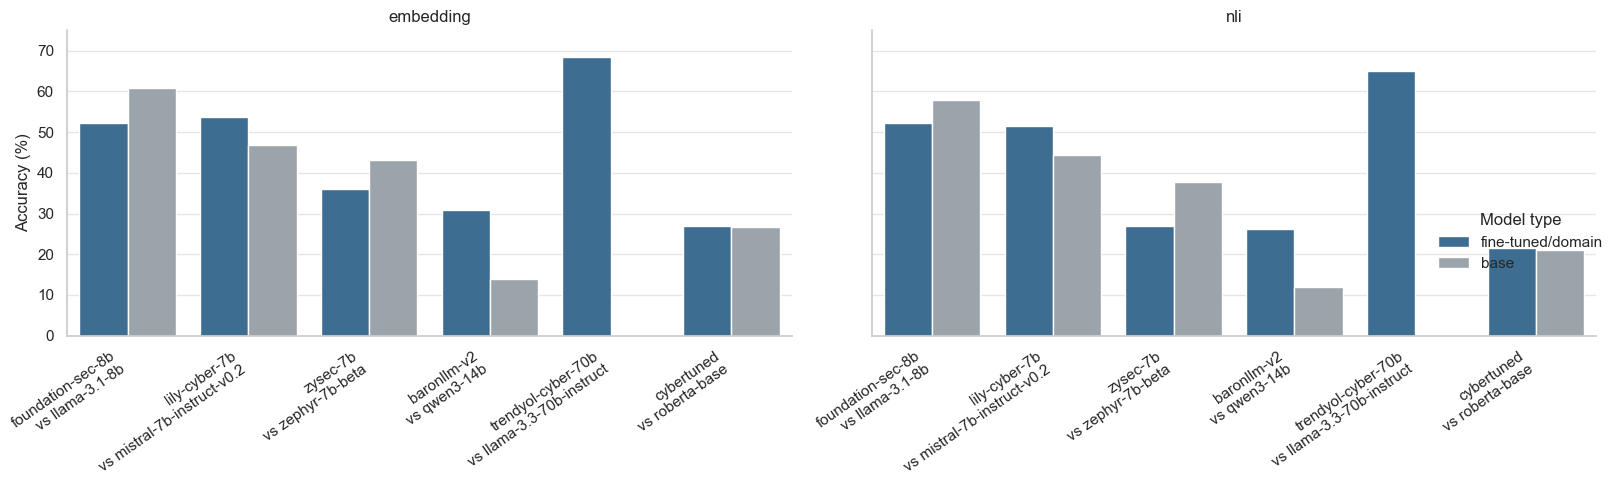

In [11]:
plot_df = df.copy()
plot_df['pair'] = plot_df['ft_model'] + '\nvs ' + plot_df['base_model']

accuracy_long = plot_df.melt(
    id_vars=['corpus', 'pair', 'ft_model', 'base_model'],
    value_vars=['ft_accuracy', 'base_accuracy'],
    var_name='model_type',
    value_name='accuracy'
).dropna(subset=['accuracy'])

accuracy_long['model_type'] = accuracy_long['model_type'].map({
    'ft_accuracy': 'fine-tuned/domain',
    'base_accuracy': 'base'
})
accuracy_long['accuracy_pct'] = accuracy_long['accuracy'] * 100

sns.set_theme(style='whitegrid', context='notebook')
g = sns.catplot(
    data=accuracy_long,
    kind='bar',
    x='pair',
    y='accuracy_pct',
    hue='model_type',
    col='corpus',
    height=5,
    aspect=1.45,
    palette={'fine-tuned/domain': '#2f6f9f', 'base': '#9aa4ad'},
    sharey=True
)
g.set_axis_labels('', 'Accuracy (%)')
g.set_titles('{col_name}')
g.legend.set_title('Model type')

for ax in g.axes.flat:
    ax.set_ylim(0, 75)
    ax.tick_params(axis='x', rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

plt.tight_layout()
plt.savefig('data/eval/base_vs_finetuned_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()

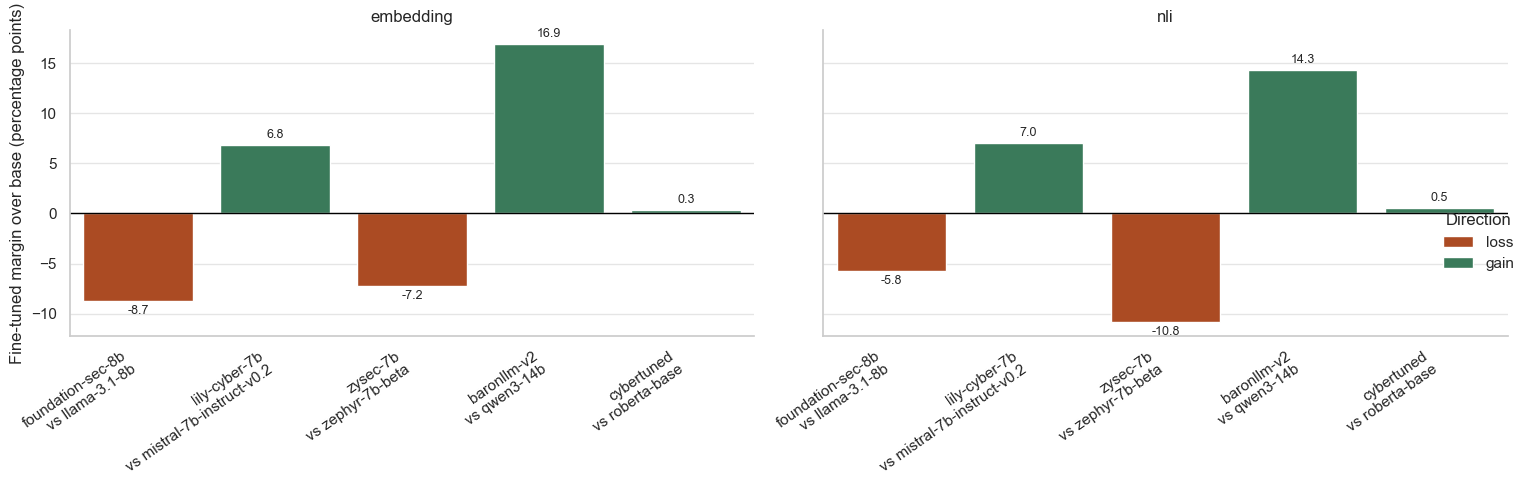

In [12]:
margin_df = df.dropna(subset=['margin_pp']).copy()
margin_df['pair'] = margin_df['ft_model'] + '\nvs ' + margin_df['base_model']
margin_df['direction'] = np.where(margin_df['margin_pp'] >= 0, 'gain', 'loss')

g = sns.catplot(
    data=margin_df,
    kind='bar',
    x='pair',
    y='margin_pp',
    hue='direction',
    col='corpus',
    height=5,
    aspect=1.45,
    palette={'gain': '#2f855a', 'loss': '#c2410c'},
    sharey=True,
    dodge=False
)
g.set_axis_labels('', 'Fine-tuned margin over base (percentage points)')
g.set_titles('{col_name}')
g.legend.set_title('Direction')

for ax in g.axes.flat:
    ax.axhline(0, color='black', linewidth=1)
    ax.tick_params(axis='x', rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('data/eval/base_vs_finetuned_margin.png', dpi=200, bbox_inches='tight')
plt.show()